## Practico Aprendizaje No Supervisado

### Importar librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

sns.set_theme(style="whitegrid")

### Cargar datos

In [2]:
male_players = pd.read_csv("../Data/male_players.csv")

C:\Users\Gonza Marengo\AppData\Local\Temp\ipykernel_25156\4161528585.py:1: DtypeWarning: Columns (0: gk) have mixed types. Specify dtype option on import or set low_memory=False.
  male_players = pd.read_csv("../Data/male_players.csv")


### Estructura del dataset y tipos de variables

El dataset analizado contiene *'180.021 filas'* y *'109 columnas'*

In [3]:
print("Dimensiones del dataset: ", male_players.shape)
print(male_players.info())

Dimensiones del dataset:  (180021, 109)
<class 'pandas.DataFrame'>
RangeIndex: 180021 entries, 0 to 180020
Columns: 109 entries, player_id to gk
dtypes: float64(20), int64(43), object(1), str(45)
memory usage: 149.7+ MB
None


### Limpieza de datos

Hacemos una copia del dataset original para no modificar el dataset original.

Notamos que las columnas con atributos de jugadores como 'ls', 'st', 'rs', son variables de tipo string, cuando en realidad deberian ser numericas, hay valores que son por ejemplo **90+3**. Procedemos a limpiar estas 27 variables y asignarle su verdadero data type.

In [4]:
# crear la copia ANTES de tocar nada
male_players_limpio = male_players.copy()

# 1. Detectar columnas afectadas (sobre la copia)
afectadas = [c for c in male_players_limpio.columns
             if male_players_limpio[c].astype(str).str.replace(" ", "", regex=False)
                                                   .str.match(r'^\d+[+-]\d+$').any()]
print("Columnas a convertir:", afectadas)
print("Cantidad de columnas a convertir:", len(afectadas))

Columnas a convertir: ['ls', 'st', 'rs', 'lw', 'lf', 'cf', 'rf', 'rw', 'lam', 'cam', 'ram', 'lm', 'lcm', 'cm', 'rcm', 'rm', 'lwb', 'ldm', 'cdm', 'rdm', 'rwb', 'lb', 'lcb', 'cb', 'rcb', 'rb', 'gk']
Cantidad de columnas a convertir: 27


In [5]:
def parse_rating(valor):
    """'90+3' -> 93, '85-2' -> 83, '90' -> 90. Nulo o no parseable -> NaN."""
    if pd.isna(valor):
        return np.nan
    s = str(valor).replace(" ", "")           # limpio espacios tipo "90 + 3"
    m = re.fullmatch(r'(\d+)([+-]\d+)?', s)   # base + modificador opcional
    if m is None:
        return np.nan
    base = int(m.group(1))
    return base + int(m.group(2)) if m.group(2) else base

In [6]:
# 2. Chequeo de seguridad
for c in afectadas:
    no_nulos_antes = male_players_limpio[c].notna().sum()
    parseables     = male_players_limpio[c].map(parse_rating).notna().sum()
    perdidos = no_nulos_antes - parseables
    if perdidos > 0:
        print(f"  ⚠ {c}: {perdidos} valores no parseables (revisar antes de seguir)")
    else:
        print(f"  ✓ {c}: OK")

  ✓ ls: OK
  ✓ st: OK
  ✓ rs: OK
  ✓ lw: OK
  ✓ lf: OK
  ✓ cf: OK
  ✓ rf: OK
  ✓ rw: OK
  ✓ lam: OK
  ✓ cam: OK
  ✓ ram: OK
  ✓ lm: OK
  ✓ lcm: OK
  ✓ cm: OK
  ✓ rcm: OK
  ✓ rm: OK
  ✓ lwb: OK
  ✓ ldm: OK
  ✓ cdm: OK
  ✓ rdm: OK
  ✓ rwb: OK
  ✓ lb: OK
  ✓ lcb: OK
  ✓ cb: OK
  ✓ rcb: OK
  ✓ rb: OK
  ✓ gk: OK


In [7]:
# 3. Aplicar la conversión SOBRE LA COPIA
for c in afectadas:
    male_players_limpio[c] = pd.to_numeric(male_players_limpio[c].map(parse_rating)).astype("Int64")

# 4. Verificar
print(male_players_limpio[afectadas].dtypes)
male_players_limpio[afectadas].head()

ls     Int64
st     Int64
rs     Int64
lw     Int64
lf     Int64
cf     Int64
rf     Int64
rw     Int64
lam    Int64
cam    Int64
ram    Int64
lm     Int64
lcm    Int64
cm     Int64
rcm    Int64
rm     Int64
lwb    Int64
ldm    Int64
cdm    Int64
rdm    Int64
rwb    Int64
lb     Int64
lcb    Int64
cb     Int64
rcb    Int64
rb     Int64
gk     Int64
dtype: object


,ls,st,rs,lw,lf,cf,rf,rw,lam,cam,...,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb,gk
0,93,93,93,91,91,91,91,91,92,92,...,66,66,66,71,66,57,57,57,66,21
1,93,93,93,82,86,86,86,82,85,85,...,66,66,66,65,63,65,65,65,63,22
2,86,86,86,87,88,88,88,87,91,91,...,83,83,83,82,78,73,73,73,78,24
3,88,88,88,90,89,89,89,90,90,90,...,66,66,66,67,62,52,52,52,62,22
4,90,90,90,86,89,89,89,86,90,90,...,67,67,67,67,63,58,58,58,63,21


In [8]:
male_players_limpio.head()

,player_id,player_url,fifa_version,fifa_update,update_as_of,short_name,long_name,player_positions,overall,potential,...,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb,gk
0,231747,/player/231747/kylian-mbappe/240002,24.0,2.0,2023-09-22,K. Mbappé,Kylian Mbappé Lottin,"ST, LW",91,94,...,66,66,66,71,66,57,57,57,66,21
1,239085,/player/239085/erling-haaland/240002,24.0,2.0,2023-09-22,E. Haaland,Erling Braut Haaland,ST,91,94,...,66,66,66,65,63,65,65,65,63,22
2,192985,/player/192985/kevin-de-bruyne/240002,24.0,2.0,2023-09-22,K. De Bruyne,Kevin De Bruyne,"CM, CAM",91,91,...,83,83,83,82,78,73,73,73,78,24
3,158023,/player/158023/lionel-messi/240002,24.0,2.0,2023-09-22,L. Messi,Lionel Andrés Messi Cuccittini,"CF, CAM",90,90,...,66,66,66,67,62,52,52,52,62,22
4,165153,/player/165153/karim-benzema/240002,24.0,2.0,2023-09-22,K. Benzema,Karim Benzema,"CF, ST",90,90,...,67,67,67,67,63,58,58,58,63,21


### Tipos de variables

Antes de trabajar con las variables conviene entender qué tenemos. Con 109 columnas,
clasificarlas primero nos permite decidir con criterio cuáles usar y cuáles descartar,
en lugar de mirarlas de a una.

Aplicamos **dos clasificaciones complementarias**:

- **Clasificación analítica** — agrupa las columnas según su tipo de dato: *numéricas*,
  *categóricas* e *identificadores*. Responde a la pregunta técnica de *cómo* está
  representada cada variable.

- **Clasificación de dominio** — agrupa las columnas según *qué representan* sobre el
  jugador (datos físicos, habilidades, valor de mercado, etc.). Responde a la pregunta
  conceptual de *qué significa* cada variable y nos ayuda a elegir cuáles alimentan
  el análisis.

A continuación listamos todas las columnas del dataset y luego las clasificamos con
ambos enfoques.

In [9]:
pd.set_option("display.max_seq_items", None)   # None = sin límite
male_players_limpio.columns

Index(['player_id', 'player_url', 'fifa_version', 'fifa_update',
       'update_as_of', 'short_name', 'long_name', 'player_positions',
       'overall', 'potential', 'value_eur', 'wage_eur', 'age', 'dob',
       'height_cm', 'weight_kg', 'club_team_id', 'club_name', 'league_id',
       'league_name', 'league_level', 'club_position', 'club_jersey_number',
       'club_loaned_from', 'club_joined_date',
       'club_contract_valid_until_year', 'nationality_id', 'nationality_name',
       'nation_team_id', 'nation_position', 'nation_jersey_number',
       'preferred_foot', 'weak_foot', 'skill_moves',
       'international_reputation', 'work_rate', 'body_type', 'real_face',
       'release_clause_eur', 'player_tags', 'player_traits', 'pace',
       'shooting', 'passing', 'dribbling', 'defending', 'physic',
       'attacking_crossing', 'attacking_finishing',
       'attacking_heading_accuracy', 'attacking_short_passing',
       'attacking_volleys', 'skill_dribbling', 'skill_curve',
       's

In [10]:
def clasificar_por_tipo(df, umbral_id=0.9):
    clasif = {"identificadores": [], "numericas": [], "categoricas": []}
    n = len(df)
    for col in df.columns:
        nombre = col.lower()
        card = df[col].nunique(dropna=True) / n
        es_id_por_nombre = nombre.endswith("_id") or "url" in nombre or nombre == "player_id"

        if es_id_por_nombre or card > umbral_id:
            clasif["identificadores"].append(col)
        elif pd.api.types.is_numeric_dtype(df[col]):
            clasif["numericas"].append(col)
        else:
            clasif["categoricas"].append(col)
    return clasif

tipos = clasificar_por_tipo(male_players_limpio)
for k, v in tipos.items():
    print(f"\n{k.upper()} ({len(v)}):\n{v}")


IDENTIFICADORES (6):
['player_id', 'player_url', 'club_team_id', 'league_id', 'nationality_id', 'nation_team_id']

NUMERICAS (85):
['fifa_version', 'fifa_update', 'overall', 'potential', 'value_eur', 'wage_eur', 'age', 'height_cm', 'weight_kg', 'league_level', 'club_jersey_number', 'club_contract_valid_until_year', 'nation_jersey_number', 'weak_foot', 'skill_moves', 'international_reputation', 'release_clause_eur', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 'attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy', 'attacking_short_passing', 'attacking_volleys', 'skill_dribbling', 'skill_curve', 'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control', 'movement_acceleration', 'movement_sprint_speed', 'movement_agility', 'movement_reactions', 'movement_balance', 'power_shot_power', 'power_jumping', 'power_stamina', 'power_strength', 'power_long_shots', 'mentality_aggression', 'mentality_interceptions', 'mentality_positioning', 'mentality_

In [11]:
grupos_dominio = {
    # Claves y metadata técnica del registro (no describen al jugador)
    "identificadores": [
        "player_id", "player_url", "fifa_version", "fifa_update",
        "update_as_of", "short_name", "long_name",
    ],

    # Contexto de club, liga, contrato y selección
    "club_contrato": [
        "club_team_id", "club_name", "league_id", "league_name",
        "league_level", "club_position", "club_jersey_number",
        "club_loaned_from", "club_joined_date", "club_contract_valid_until_year",
        "nation_team_id", "nation_position", "nation_jersey_number",
    ],

    # Origen del jugador
    "nacionalidad": ["nationality_id", "nationality_name"],

    # Valor de mercado y salario (reflejan mercado, no habilidad pura)
    "economicas": ["value_eur", "wage_eur", "release_clause_eur"],

    # Datos personales y físicos
    "demograficas_fisicas": ["age", "dob", "height_cm", "weight_kg", "preferred_foot"],

    # Notas globales que resumen todo el jugador
    "valoraciones_globales": ["overall", "potential"],

    # Rasgos cualitativos de estilo y reputación
    "perfil_meta": [
        "weak_foot", "skill_moves", "international_reputation", "work_rate",
        "body_type", "real_face", "player_tags", "player_traits", "player_positions",
    ],

    # Las 6 notas agregadas de habilidad
    "agregadas": ["pace", "shooting", "passing", "dribbling", "defending", "physic"],

    # Atributos técnicos granulares de jugador de campo (el corazón del perfil)
    "granulares": [
        "attacking_crossing", "attacking_finishing", "attacking_heading_accuracy",
        "attacking_short_passing", "attacking_volleys",
        "skill_dribbling", "skill_curve", "skill_fk_accuracy",
        "skill_long_passing", "skill_ball_control",
        "movement_acceleration", "movement_sprint_speed", "movement_agility",
        "movement_reactions", "movement_balance",
        "power_shot_power", "power_jumping", "power_stamina",
        "power_strength", "power_long_shots",
        "mentality_aggression", "mentality_interceptions", "mentality_positioning",
        "mentality_vision", "mentality_penalties", "mentality_composure",
        "defending_marking_awareness", "defending_standing_tackle", "defending_sliding_tackle",
    ],

    # Atributos exclusivos de arquero (nulos estructurales para jugadores de campo)
    "arquero": [
        "goalkeeping_diving", "goalkeeping_handling", "goalkeeping_kicking",
        "goalkeeping_positioning", "goalkeeping_reflexes", "goalkeeping_speed",
    ],

    # Las 27 valoraciones por posición que ya limpiaste (redundantes entre sí)
    "ratings_posicion": [
        "ls", "st", "rs", "lw", "lf", "cf", "rf", "rw", "lam", "cam", "ram",
        "lm", "lcm", "cm", "rcm", "rm", "lwb", "ldm", "cdm", "rdm", "rwb",
        "lb", "lcb", "cb", "rcb", "rb", "gk",
    ],
}

In [12]:
# Invertir los diccionarios: de {grupo: [columnas]} a {columna: grupo}
col_a_analitica = {c: grupo for grupo, cols in tipos.items() for c in cols}
col_a_dominio   = {c: grupo for grupo, cols in grupos_dominio.items() for c in cols}

n = len(male_players_limpio)
filas = []
for col in male_players_limpio.columns:
    s = male_players_limpio[col]
    nulos = s.isna().sum()
    ejemplo = s.dropna().iloc[0] if s.notna().any() else None
    filas.append({
        "columna":    col,
        "analitica":  col_a_analitica.get(col, "??"),
        "dominio":    col_a_dominio.get(col, "??"),
        "dtype":      s.dtype,
        "unicos":     s.nunique(dropna=True),
        "nulos":      nulos,
        "pct_nulos":  round(nulos / n * 100, 1),
        "ejemplo":    ejemplo,
    })

resumen = pd.DataFrame(filas)
pd.set_option("display.max_rows", 200)
resumen

,columna,analitica,dominio,dtype,unicos,nulos,pct_nulos,ejemplo
0,player_id,identificadores,identificadores,int64,53111,0,0.0,231747
1,player_url,identificadores,identificadores,str,180021,0,0.0,/player/231747/kylian-mbappe/240002
2,fifa_version,numericas,identificadores,float64,10,0,0.0,24.0
3,fifa_update,numericas,identificadores,float64,1,0,0.0,2.0
4,update_as_of,categoricas,identificadores,str,10,0,0.0,2023-09-22
5,short_name,categoricas,identificadores,str,47272,0,0.0,K. Mbappé
6,long_name,categoricas,identificadores,str,52892,0,0.0,Kylian Mbappé Lottin
7,player_positions,categoricas,perfil_meta,str,2031,0,0.0,"ST, LW"
8,overall,numericas,valoraciones_globales,int64,55,0,0.0,91
9,potential,numericas,valoraciones_globales,int64,54,0,0.0,94


#### Conteo segun clasificacion:

In [13]:
print("Por clasificación analítica:")
print(resumen["analitica"].value_counts(), "\n")
print("Por clasificación de dominio:")
print(resumen["dominio"].value_counts())

Por clasificación analítica:
analitica
numericas          85
categoricas        18
identificadores     6
Name: count, dtype: int64 

Por clasificación de dominio:
dominio
granulares               29
ratings_posicion         27
club_contrato            13
perfil_meta               9
identificadores           7
agregadas                 6
arquero                   6
demograficas_fisicas      5
economicas                3
valoraciones_globales     2
nacionalidad              2
Name: count, dtype: int64


#### Validación de la clasificación de dominio

La clasificación de dominio se armó **a mano**, escribiendo los 109 nombres de columna
repartidos en grupos. Ese proceso manual es propenso a tres errores fáciles de cometer
y difíciles de ver a simple vista: olvidar una columna, escribir mal un nombre, o repetir
la misma columna en dos grupos.

Antes de confiar en la clasificación, verificamos que sea **completa y consistente** con
tres chequeos:

1. **Columnas sin clasificar** — que estén las 109 y no falte ninguna.
2. **Nombres inexistentes** — que no haya *typos* ni columnas inventadas que no existan en el dataset.
3. **Columnas duplicadas** — que ninguna columna aparezca en más de un grupo.

Si los tres chequeos devuelven un resultado vacío (`set()` y `[]`), la clasificación
cubre cada columna exactamente una vez y podemos usarla con confianza.

In [14]:
todas = set(male_players_limpio.columns)
clasificadas = [c for cols in grupos_dominio.values() for c in cols]

# 1. columnas que existen pero no clasifiqué
faltantes = todas - set(clasificadas)
print("Sin clasificar:", faltantes)

# 2. nombres que puse pero no existen (typos)
inventadas = set(clasificadas) - todas
print("Inventadas o mal escritas:", inventadas)

# 3. columnas repetidas en más de un grupo
from collections import Counter
duplicadas = [c for c, n in Counter(clasificadas).items() if n > 1]
print("Duplicadas en 2+ grupos:", duplicadas)

Sin clasificar: set()
Inventadas o mal escritas: set()
Duplicadas en 2+ grupos: []


Los tres chequeos devolvieron vacío: la clasificación de dominio es completa (están las
109 columnas), correcta (sin nombres mal escritos) y consistente (sin solapamientos entre
grupos). Podemos avanzar usándola como base para seleccionar las variables del análisis.

### Tratamiento de valores nulos

Hacemos un analisis de las variables que tienen mas de un 50% de valores nulos en la tabla de clasificacion previa.

In [15]:
# columnas con más del 50% de nulos, según la tabla de clasificación
umbral = 15
cols_muchos_nulos = resumen[resumen["pct_nulos"] > umbral]["columna"].tolist()

print(f"{len(cols_muchos_nulos)} columnas superan el {umbral}% de nulos:")
print(cols_muchos_nulos)

9 columnas superan el 15% de nulos:
['club_loaned_from', 'nation_team_id', 'nation_position', 'nation_jersey_number', 'release_clause_eur', 'player_tags', 'player_traits', 'mentality_composure', 'goalkeeping_speed']


In [16]:
df_nulos = male_players_limpio[cols_muchos_nulos]

tabla_nulos = (
    resumen[resumen["pct_nulos"] > umbral]     # filtro: solo las que superan el umbral
    [["columna", "pct_nulos"]]                 # me quedo con esas dos columnas
    .sort_values("pct_nulos", ascending=False) # ordeno de mayor a menor % de nulos
    .reset_index(drop=True)                    # reinicio el índice (0, 1, 2...)
)

tabla_nulos

,columna,pct_nulos
0,nation_team_id,94.4
1,nation_jersey_number,94.4
2,nation_position,94.4
3,club_loaned_from,94.0
4,player_tags,92.3
5,goalkeeping_speed,88.9
6,player_traits,54.6
7,release_clause_eur,32.9
8,mentality_composure,18.3


Decidimos analizar mas a fondo la variable 'mentality_composure' (al ser la variable con menor cantidad de nulos de todas las variables encontradas con mas de 15% de nulos) para ver si servia bien para la separacion de los clusters. Si el boxplot nos muestra que la variable sabe separar bien por roles macro de futbolistas, la dejamos dentro para seguir, en el caso de que no sirva, la descartamos junto con el resto de variables encontradas con mas de 15% de nulos porque todo el resto de estas tiene una importante cantidad de nulos.

En cuanto a las variables que tengan menos del 15% de valores nulos, mas adelante en el trabajo se trataran correctamente.

In [17]:
def rol_macro(posiciones):
    if pd.isna(posiciones):
        return "sin_dato"
    prim = str(posiciones).split(",")[0].strip().upper()   # tomo la posición PRINCIPAL
    if prim == "GK":
        return "arquero"
    if prim in {"CB", "LB", "RB", "LWB", "RWB", "LCB", "RCB"}:
        return "defensor"
    if prim in {"CDM", "CM", "CAM", "LM", "RM", "LDM", "RDM", "LCM", "RCM", "LAM", "RAM"}:
        return "mediocampista"
    if prim in {"ST", "CF", "LW", "RW", "LF", "RF", "LS", "RS", "SS"}:
        return "delantero"
    return "otro"

male_players_limpio["rol"] = male_players_limpio["player_positions"].map(rol_macro)
print(male_players_limpio["rol"].value_counts())

rol
mediocampista    66551
defensor         58935
delantero        34510
arquero          20025
Name: count, dtype: int64


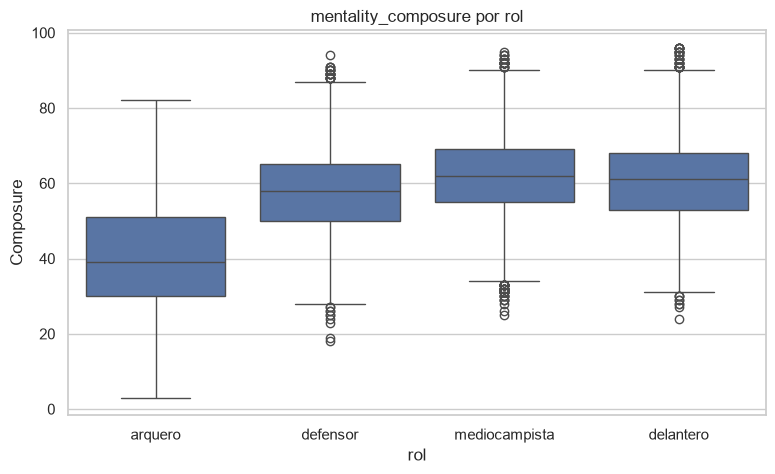

In [18]:
orden = ["arquero", "defensor", "mediocampista", "delantero"]

plt.figure(figsize=(9, 5))
sns.boxplot(data=male_players_limpio, x="rol", y="mentality_composure", order=orden)
plt.title("mentality_composure por rol")
plt.ylabel("Composure")
plt.show()

In [19]:
# columnas que superan el 0% de nulos, según la tabla resumen
a_eliminar = resumen[resumen["pct_nulos"] > 15]["columna"].tolist()
print(f"Se van a eliminar {len(a_eliminar)} columnas:")
print(a_eliminar)

# eliminarlas de la copia de trabajo
male_players_limpio = male_players_limpio.drop(columns=a_eliminar, errors="ignore")
print(f"Shape ahora: {male_players_limpio.shape}")

Se van a eliminar 9 columnas:
['club_loaned_from', 'nation_team_id', 'nation_position', 'nation_jersey_number', 'release_clause_eur', 'player_tags', 'player_traits', 'mentality_composure', 'goalkeeping_speed']
Shape ahora: (180021, 101)


### Seleccion de variables para el problema de clustering

In [55]:
to_del = ['value_eur', 'wage_eur', 'release_clause_eur', 'age', 'dob']
to_del += grupos_dominio['nacionalidad']
to_del += [c for c in grupos_dominio['identificadores'] if c != 'long_name']
to_del += [c for c in grupos_dominio['club_contrato'] if c != 'club_position']
to_del += [c for c in grupos_dominio['perfil_meta']]
to_del += ['preferred_foot', 'height_cm', 'weight_kg', 'club_position']

print("Cantidad de variables a eliminar:", len(to_del))

Cantidad de variables a eliminar: 38


Hay algunas variables incluidas en la lista 'to_del' que ya estaban eliminadas antes, por eso quedan 74 columnas restantes a continuacion.

In [56]:
male_players_limpio.drop(columns=to_del, errors="ignore", inplace=True)
male_players_limpio.shape

(180021, 70)

Vamos a procedeer a analizar a las variables que todavia tienen valores nulos, despues de la limpieza de las variables que tenian una proporcion de nulos muy alta.

In [57]:
variables_con_nulos = [col for col in male_players_limpio.columns if male_players_limpio[col].isnull().any()]
variables_con_nulos
 

['pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']

In [58]:
male_players_limpio[variables_con_nulos].isna().sum()

pace         20024
shooting     20024
passing      20024
dribbling    20024
defending    20024
physic       20024
dtype: int64

Tenemos la sospecha de que la coincidencia de la cantidad de valores nulos en las variables agregadas, no es coincidencia. Estas variables son notas de habilidad de **campo**, osea que los arqueros no las tienen, vamos a chequear esa hipotesis en la celda siguiente.

Efectivamente todos los valores nulos de las variables de notas de habilidad de campo son los arqueros, entonces no se debe imputar.

In [62]:
sin_agregadas = male_players_limpio["pace"].isna()
n_arqueros = male_players_limpio.loc[sin_agregadas, "rol"].value_counts()

print("="*45)
print(f"  ARQUEROS DETECTADOS: {sin_agregadas.sum():,}")
print("="*45)
print(n_arqueros)

  ARQUEROS DETECTADOS: 20,024
rol
arquero    20024
Name: count, dtype: int64


In [61]:
male_players_limpio['rol'].value_counts()

rol
mediocampista    66551
defensor         58935
delantero        34510
arquero          20025
Name: count, dtype: int64

Confirmamos que la cantidad de arqueros en el dataset coincide con la cantidad de valores nulos en las variables que iden las notas en habilidades en el campo. Vamos a dividir en arqueros y resto y hacer el clustering en los que no son arqueros.

### Analisis descriptivo

#### Variables numericas

In [39]:
for grupo, cols in grupos_dominio.items():
    # columnas de esta familia que (a) siguen presentes y (b) son numéricas
    presentes = [c for c in cols
                 if c in male_players_limpio.columns
                 and pd.api.types.is_numeric_dtype(male_players_limpio[c])]
    if not presentes:
        continue

    print(f"\n{'='*70}")
    print(f"  {grupo.upper()}  ({len(presentes)} variables numéricas)")
    print('='*70)
    with pd.option_context("display.max_columns", None):
        display(male_players_limpio[presentes].describe().T.round(2))


  VALORACIONES_GLOBALES  (2 variables numéricas)


,count,mean,std,min,25%,50%,75%,max
overall,180021.0,65.71,7.02,40.0,61.0,66.0,70.0,94.0
potential,180021.0,70.78,6.26,40.0,66.0,71.0,75.0,95.0



  AGREGADAS  (6 variables numéricas)


,count,mean,std,min,25%,50%,75%,max
pace,159997.0,68.06,11.06,21.0,62.0,69.0,76.0,97.0
shooting,159997.0,52.27,13.92,14.0,42.0,54.0,63.0,94.0
passing,159997.0,57.00,10.43,20.0,50.0,58.0,64.0,94.0
dribbling,159997.0,62.16,10.22,22.0,56.0,63.0,69.0,96.0
defending,159997.0,51.23,16.58,14.0,36.0,56.0,64.0,91.0
physic,159997.0,64.82,9.76,27.0,58.0,66.0,72.0,92.0



  GRANULARES  (28 variables numéricas)


,count,mean,std,min,25%,50%,75%,max
attacking_crossing,180021.0,49.62,17.99,5.0,38.0,54.0,63.0,95.0
attacking_finishing,180021.0,45.69,19.28,2.0,30.0,49.0,62.0,96.0
attacking_heading_accuracy,180021.0,52.21,17.15,4.0,44.0,55.0,64.0,95.0
attacking_short_passing,180021.0,58.43,14.65,7.0,53.0,62.0,68.0,95.0
attacking_volleys,180021.0,42.97,17.45,3.0,30.0,44.0,56.0,93.0
skill_dribbling,180021.0,55.30,18.61,2.0,48.0,61.0,68.0,97.0
skill_curve,180021.0,47.35,18.06,4.0,35.0,49.0,61.0,94.0
skill_fk_accuracy,180021.0,43.03,17.20,3.0,31.0,42.0,56.0,95.0
skill_long_passing,180021.0,52.71,15.17,5.0,43.0,56.0,64.0,95.0
skill_ball_control,180021.0,58.25,16.58,5.0,54.0,63.0,69.0,96.0



  ARQUERO  (5 variables numéricas)


,count,mean,std,min,25%,50%,75%,max
goalkeeping_diving,180021.0,16.51,17.66,1.0,8.0,11.0,14.0,91.0
goalkeeping_handling,180021.0,16.26,16.85,1.0,8.0,11.0,14.0,92.0
goalkeeping_kicking,180021.0,16.13,16.50,1.0,8.0,11.0,14.0,95.0
goalkeeping_positioning,180021.0,16.28,17.01,1.0,8.0,11.0,14.0,92.0
goalkeeping_reflexes,180021.0,16.62,17.97,1.0,8.0,11.0,14.0,94.0



  RATINGS_POSICION  (27 variables numéricas)


,count,mean,std,min,25%,50%,75%,max
ls,180021.0,55.75,13.53,15.0,49.0,58.0,65.0,94.0
st,180021.0,55.75,13.53,15.0,49.0,58.0,65.0,94.0
rs,180021.0,55.75,13.53,15.0,49.0,58.0,65.0,94.0
lw,180021.0,55.52,14.43,13.0,49.0,59.0,65.0,95.0
lf,180021.0,55.26,14.16,14.0,49.0,58.0,65.0,94.0
cf,180021.0,55.26,14.16,14.0,49.0,58.0,65.0,94.0
rf,180021.0,55.26,14.16,14.0,49.0,58.0,65.0,94.0
rw,180021.0,55.52,14.43,13.0,49.0,59.0,65.0,95.0
lam,180021.0,56.88,13.96,16.0,51.0,60.0,66.0,95.0
cam,180021.0,56.88,13.96,16.0,51.0,60.0,66.0,95.0


Vamos a analizar a continuacion la varianza de cada vairiable numerica para tener una idea de las variables que mas varianza tienen.

#### Variables categoricas

In [41]:
categoricas = male_players_limpio.select_dtypes(include=["object", "category", "str"])
print(f"{categoricas.shape[1]} columnas categóricas:")
categoricas_list = categoricas.columns.tolist()
print(categoricas_list)

3 columnas categóricas:
['long_name', 'club_position', 'rol']


In [42]:
male_players_limpio[categoricas_list].describe()

,long_name,club_position,rol
count,180021,178156,180021
unique,52892,29,4
top,Danny Ward,SUB,mediocampista
freq,20,77123,66551


In [64]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Subconjunto de campo (sin arqueros)
campo = male_players_limpio[male_players_limpio["rol"] != "arquero"].copy()
print(f"Jugadores de campo: {len(campo):,}")

# 2. Las granulares presentes
gran = [c for c in grupos_dominio["granulares"] if c in campo.columns]
print(f"Granulares: {len(gran)} variables")

# 3. CHEQUEO CLAVE: ¿quedan nulos en las granulares tras sacar arqueros?
nulos_gran = campo[gran].isna().sum()
print("\nGranulares con nulos (deberían ser 0 o muy pocos):")
print(nulos_gran[nulos_gran > 0] if nulos_gran.sum() > 0 else "Ninguna, limpio ✓")

Jugadores de campo: 159,996
Granulares: 28 variables

Granulares con nulos (deberían ser 0 o muy pocos):
Ninguna, limpio ✓


In [65]:
# 4. Escalar (imprescindible) y hacer PCA
X_gran = campo[gran]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_gran)

# n_components=0.90 → PCA elige cuántas comp. hacen falta para el 90% de varianza
pca = PCA(n_components=0.90)
X_pca = pca.fit_transform(X_scaled)

print(f"{len(gran)} granulares → {pca.n_components_} componentes (90% varianza)")
print(f"\nVarianza por componente:")
for i, v in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {v*100:5.1f}%")

28 granulares → 12 componentes (90% varianza)

Varianza por componente:
  PC1:  39.2%
  PC2:  21.5%
  PC3:  10.2%
  PC4:   6.3%
  PC5:   2.6%
  PC6:   2.3%
  PC7:   2.0%
  PC8:   1.6%
  PC9:   1.5%
  PC10:   1.4%
  PC11:   1.2%
  PC12:   1.1%


In [66]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# X_pca son las 12 componentes que ya calculaste
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    sil = silhouette_score(X_pca, labels)
    print(f"k={k}: silueta = {sil:.3f} | inercia = {km.inertia_:,.0f}")

k=2: silueta = 0.250 | inercia = 2,913,166


KeyboardInterrupt: 